# Procesamiento de imágenes digitales (Ecualización del histograma)


Importar librerias requeridas

In [1]:
import numpy as np
import scipy.signal
import cv2 as cv
from matplotlib import pyplot as plt
from PIL import Image

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd '/content/drive/MyDrive/UIS/2026-1/Procesamiento de imágenes dígitales/Quices/Quiz #2: Ecualización del Histograma'

/content/drive/MyDrive/UIS/2026-1/Procesamiento de imágenes dígitales/Quices/Quiz #2: Ecualización del Histograma


Importar imagen para hacer las pruebas (en escala de grises o color)
https://github.com/hfarueda/DIP/blob/main/Imagenes/


In [4]:
# A veces funciona, a veces no, entonces mejor montar el Gdrive
#!wget https://github.com/hfarueda/DIP/blob/main/Imagenes/Einstein_2_lowcontrast.tif

# Ecualización del Histograma


In [5]:
image = cv.imread('Einstein_1_lowcontrast.tif')



In [6]:
image.dtype

dtype('uint8')

In [7]:
# Convertir y dividir la imagen LAB (Luminance = Lightness) L es como calcular la media de los 3 canales
lab_img = cv.cvtColor(image, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab_img)

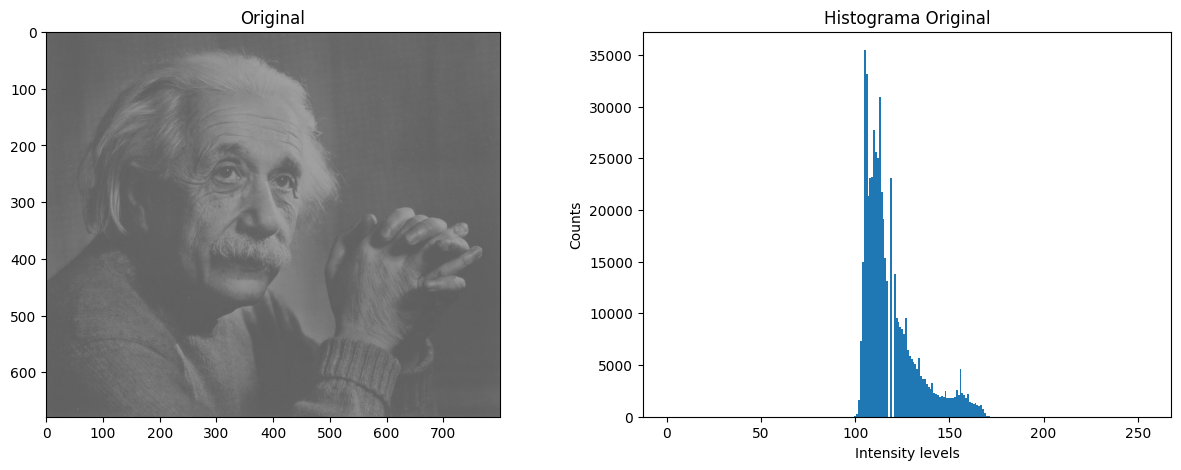

In [8]:
# Mostrar imagen original de luminancia y su histograma
plt.figure(figsize=(15,5))
plt.subplot(121), plt.imshow(image), plt.title('Original');
plt.subplot(122), plt.hist(l.ravel(), bins=256, range=(0,255)); plt.xlabel('Intensity levels'); plt.ylabel('Counts'); plt.title('Histograma Original');

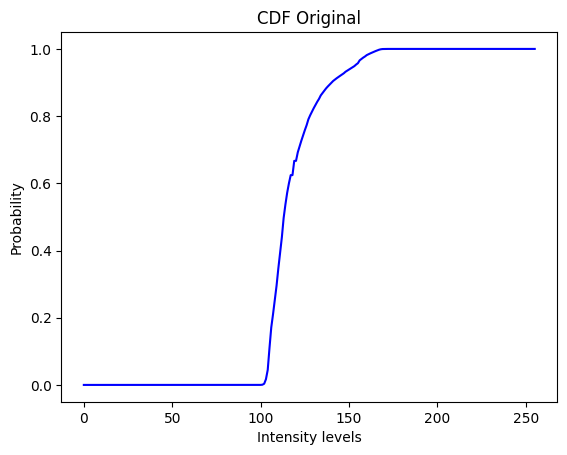

In [9]:
# Calculemos la CDF y analicemosla
hist, bins = np.histogram(l.flatten(),256,[0,256])
cdf = hist.cumsum()
cdf_norm_orig = cdf / cdf.max()
plt.plot(cdf_norm_orig, color = 'b'), plt.xlabel('Intensity levels'); plt.ylabel('Probability'); plt.title('CDF Original');
plt.show()

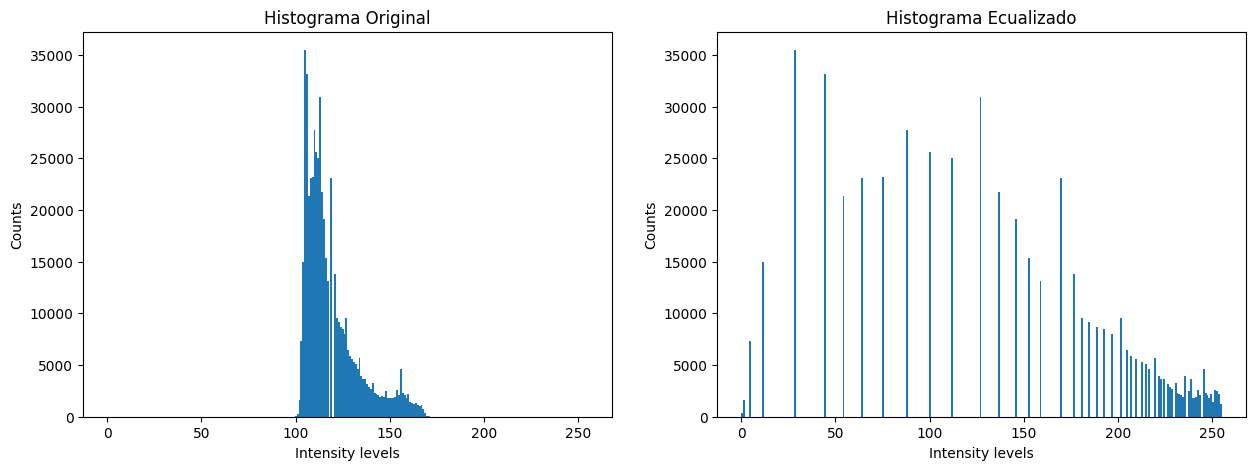

In [10]:
# Aplicar ecualización de histograma al canal L
equ = cv.equalizeHist(l)

plt.figure(figsize=(15,5))
plt.subplot(121), plt.hist(l.ravel(), bins=256, range=(0,255)); plt.xlabel('Intensity levels'); plt.ylabel('Counts'); plt.title('Histograma Original');
plt.subplot(122), plt.hist(equ.flat, bins=256, range=(0,255)), plt.xlabel('Intensity levels'); plt.ylabel('Counts'); plt.title('Histograma Ecualizado');

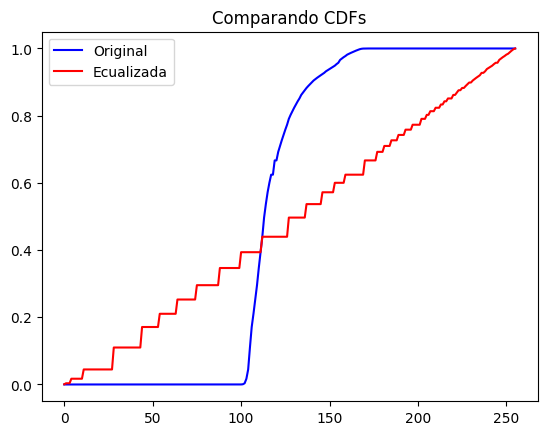

In [11]:
hist, bins = np.histogram(equ.flatten(),256,[0,256])
cdf = hist.cumsum()
cdf_norm_eq = cdf / cdf.max()
plt.plot(cdf_norm_orig, color = 'b')
plt.plot(cdf_norm_eq, color = 'r')
plt.title('Comparando CDFs')
plt.legend(["Original", "Ecualizada"], loc="upper left")
plt.show()

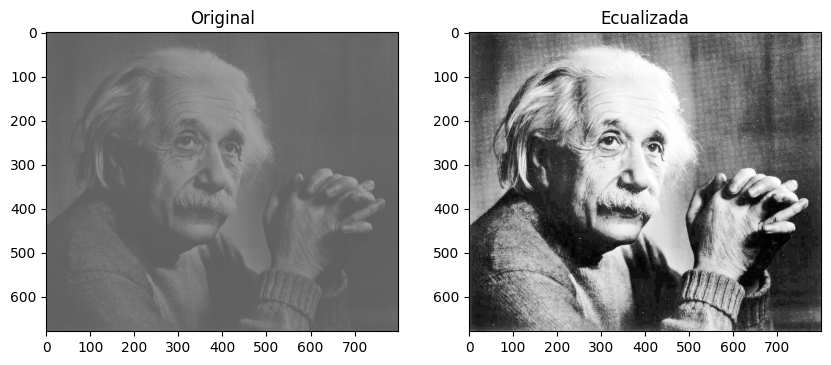

In [12]:
# Combine la imagen ecualizada con los canales a y b, y conviertala de vuelta a RGB
updated_lab_img1 = cv.merge((equ,a,b))
hist_eq_img = cv.cvtColor(updated_lab_img1, cv.COLOR_LAB2BGR)

plt.figure(figsize=(10,10))
plt.subplot(121), plt.imshow(image), plt.title('Original');
plt.subplot(122), plt.imshow(hist_eq_img), plt.title('Ecualizada');

# CLAHE (Contrast Limited Adaptive Histogram Equalization)
Una mejor manera de ecualizar un histograma se logra a través de la ecualización de histograma adaptativa. En este, la imagen se divide en pequeños bloques llamados "mosaicos" (tileSize es 8x8 de forma predeterminada en OpenCV). Luego, cada uno de estos bloques se ecualiza como de costumbre. Entonces, en un área pequeña, el histograma se limitaría a una región pequeña (a menos que haya ruido). Si hay ruido, se amplificará. Para evitar esto, se aplica limitación de contraste. Si algún "bin" del histograma está por encima del límite de contraste especificado (por defecto 40 en OpenCV), esos píxeles se recortan y distribuyen uniformemente a otros "bins" antes de aplicar la ecualización del histograma. Después de la ecualización, para eliminar artefactos en los bordes de los mosaicos, se aplica la interpolación bilineal.

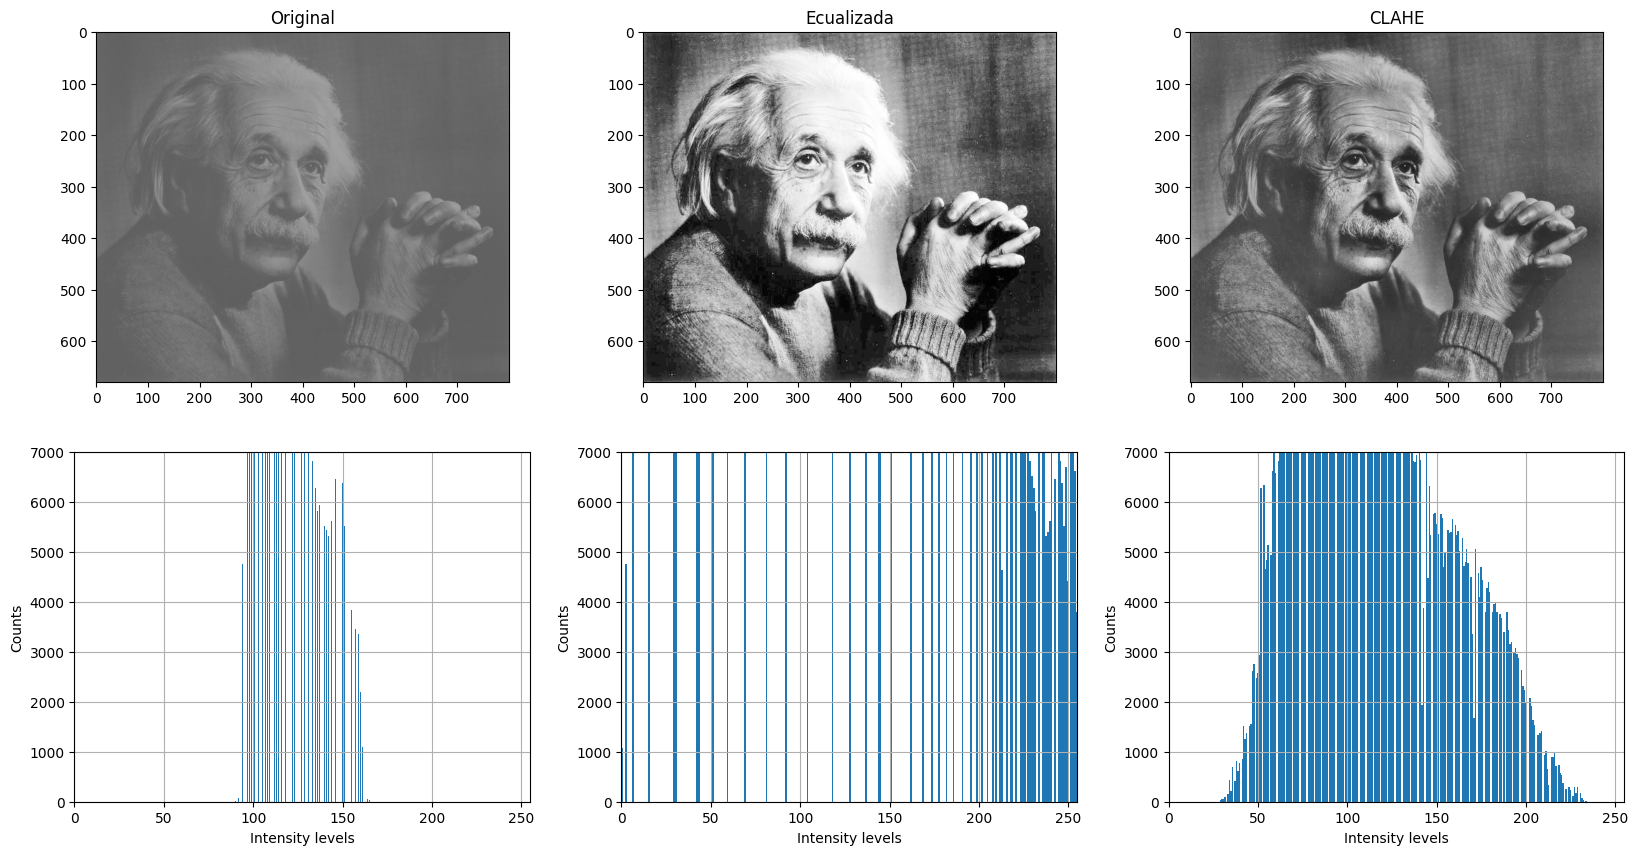

In [13]:
# Cree y aplique CLAHE al canal L
clahe = cv.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
clahe_img = clahe.apply(l)

# Recombine y convierta de vuelta a RGB
updated_lab_img2 = cv.merge((clahe_img,a,b))
CLAHE_img = cv.cvtColor(updated_lab_img2, cv.COLOR_LAB2BGR)

# Plot
plt.figure(figsize=(20,10))
plt.subplot(231), plt.imshow(image), plt.title('Original')
plt.subplot(232), plt.imshow(hist_eq_img), plt.title('Ecualizada')
plt.subplot(233), plt.imshow(CLAHE_img), plt.title('CLAHE')
plt.subplot(234), plt.hist(image.ravel(),256), plt.axis([0,255,0,7e3]), plt.grid(True); plt.xlabel('Intensity levels'); plt.ylabel('Counts');
plt.subplot(235), plt.hist(hist_eq_img.ravel(),256), plt.axis([0,255,0,7e3]), plt.grid(True); plt.xlabel('Intensity levels'); plt.ylabel('Counts');
plt.subplot(236), plt.hist(CLAHE_img.ravel(),256), plt.axis([0,255,0,7e3]), plt.grid(True); plt.xlabel('Intensity levels'); plt.ylabel('Counts');

# Reto del Notebook: Ecualización del histograma (A mano)

array([[116, 115, 114, ..., 119, 121, 122],
       [115, 115, 114, ..., 121, 122, 123],
       [114, 114, 113, ..., 119, 121, 121],
       ...,
       [111, 111, 111, ..., 112, 113, 113],
       [112, 112, 112, ..., 112, 113, 113],
       [113, 113, 113, ..., 113, 113, 114]], dtype=uint8)
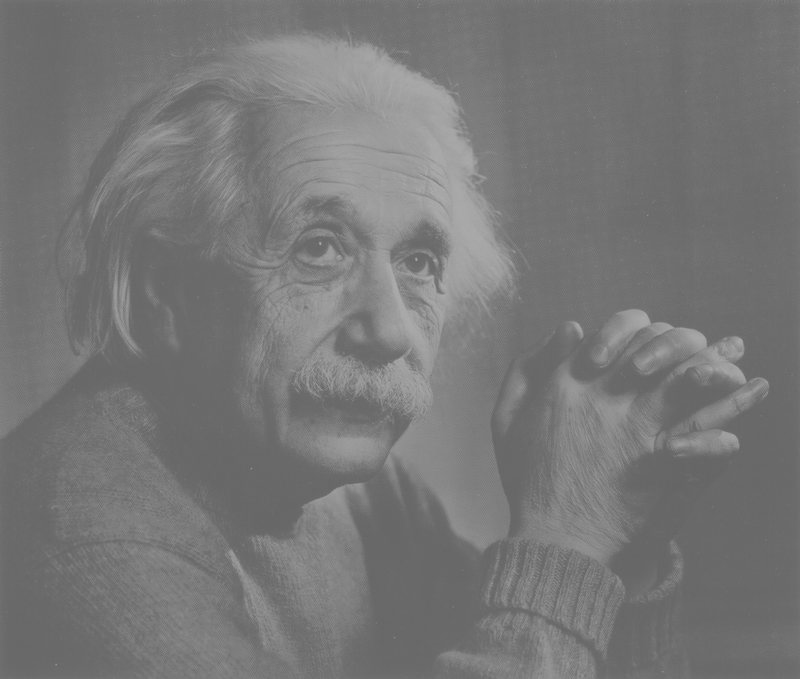

In [14]:
l

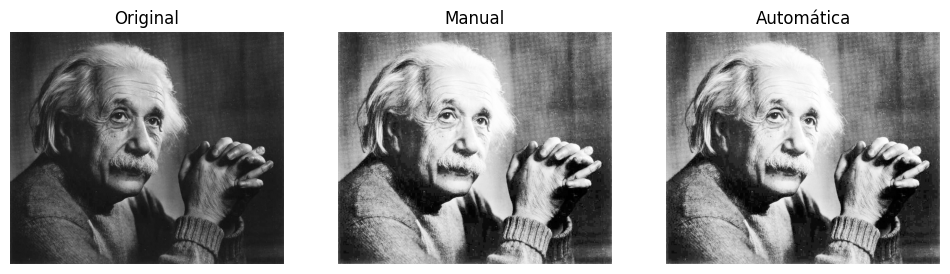

In [21]:
""" PASO 1: Calcule el histograma acumulado normalizado """

hist, bins = np.histogram(l.flatten(), bins=256, range=[0,256])
cdf = hist.cumsum()
cdf_norm = cdf / cdf.max()

""" PASO 2: Calcule la LUT de la transformación """

L = 256
lut = np.floor((L - 1) * cdf_norm).astype('uint8')


""" PASO 3: Aplique la Transformación """
img_eq_manual = lut[l]


""" PASO 4: Grafique su resultado y comparelo con la original y la ecualizada automáticamente """
img_eq_auto = cv.equalizeHist(l)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(l, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Manual")
plt.imshow(img_eq_manual, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Automática")
plt.imshow(img_eq_auto, cmap='gray')
plt.axis('off')

plt.show()

In [16]:
# Resultado esperado:

# Estiramiento del contraste (Contrast Stretching)


![ContrastStretch](https://www.tutorialspoint.com/dip/images/stretching3.jpg)

# Reto No. 2: Implementa el estiramiento de contraste y compara con la ecualizada

In [17]:
I = l
Imin = I.min() #Aqui tu codigo
Imax = I.max() #Aqui tu codigo
Is = ((I-Imin)/(Imax-Imin)) * 255 #Aqui tu codigo

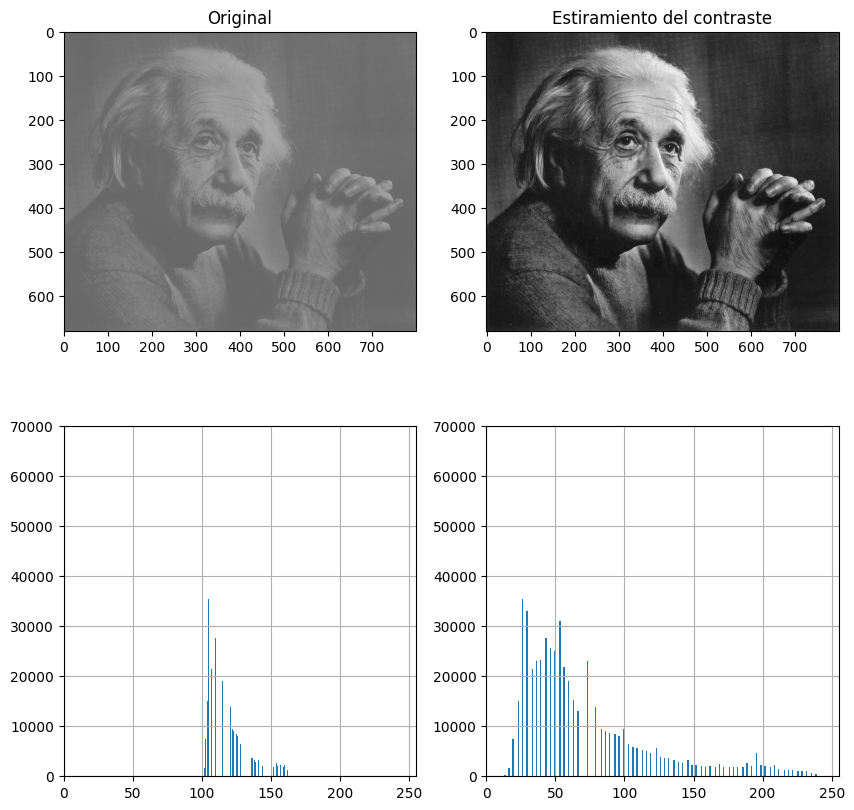

In [18]:
# Grafica la imagen original, vs la estiramiento del contraste y sus correspondientes histogramas
plt.figure(figsize=(10,10))
plt.subplot(221), plt.imshow(I,'gray',vmin=0, vmax=255), plt.title('Original')
plt.subplot(222), plt.imshow(Is,'gray',vmin=0, vmax=255), plt.title('Estiramiento del contraste')
plt.subplot(223), plt.hist(I.ravel(),256), plt.axis([0,255,0,70e3]), plt.grid(True)
plt.subplot(224), plt.hist(Is.ravel(),256), plt.axis([0,255,0,70e3]), plt.grid(True);

In [19]:
# Resultado de la ejecución:

# Diferencia entre Estiramiento de Contraste y Ecualización del Histograma?

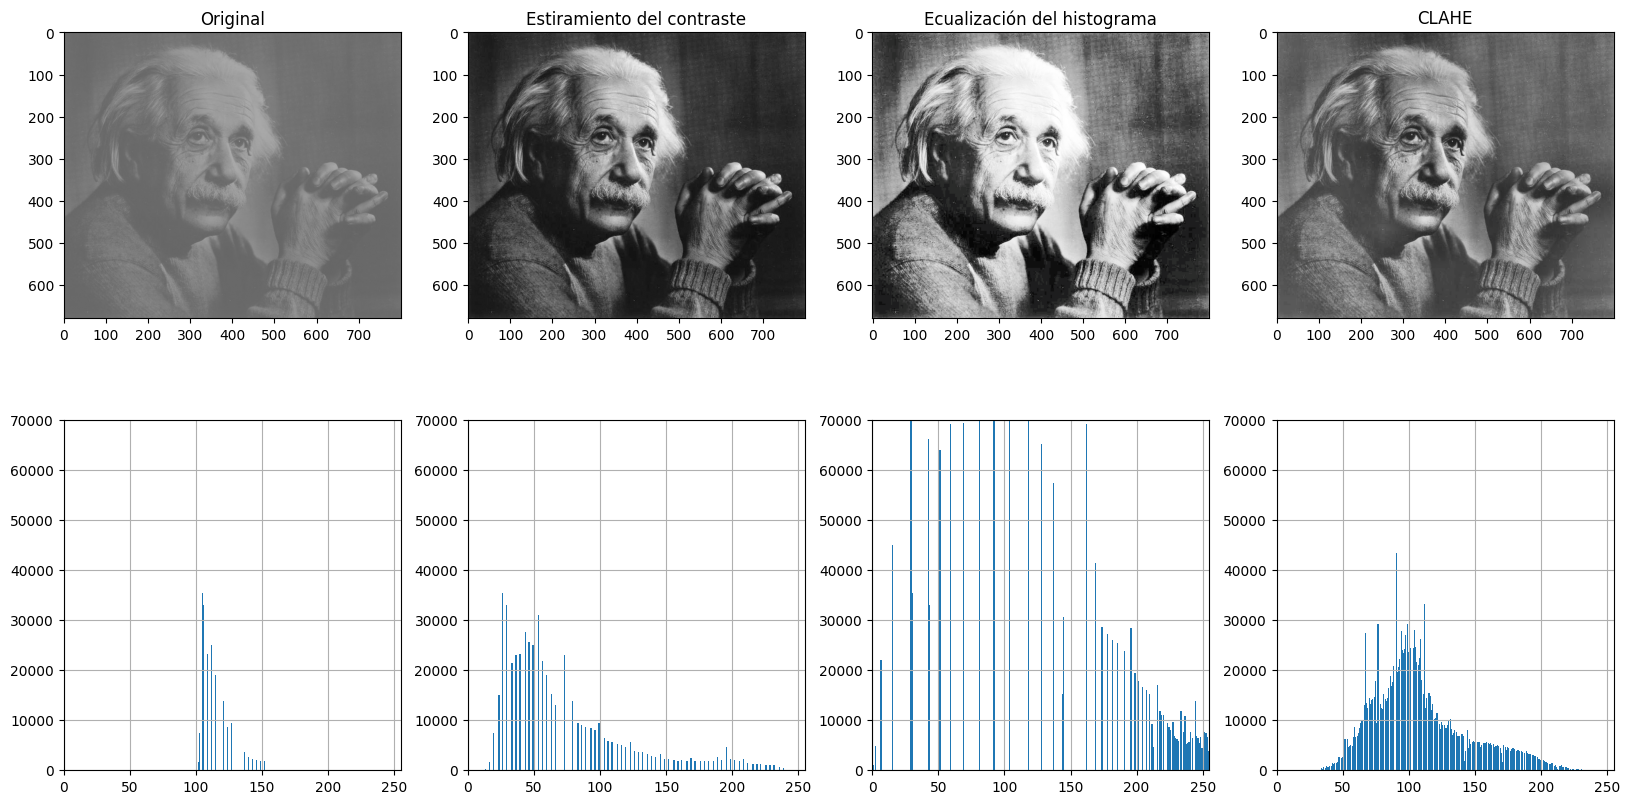

In [20]:
# Plot
plt.figure(figsize=(20,10))
plt.subplot(241), plt.imshow(I,'gray',vmin=0, vmax=255), plt.title('Original')
plt.subplot(242), plt.imshow(Is,'gray',vmin=0, vmax=255), plt.title('Estiramiento del contraste')
plt.subplot(243), plt.imshow(hist_eq_img,'gray',vmin=0, vmax=255), plt.title('Ecualización del histograma')
plt.subplot(244), plt.imshow(CLAHE_img,'gray',vmin=0, vmax=255), plt.title('CLAHE')
plt.subplot(245), plt.hist(I.ravel(),256), plt.axis([0,255,0,70e3]), plt.grid(True)
plt.subplot(246), plt.hist(Is.ravel(),256), plt.axis([0,255,0,70e3]), plt.grid(True);
plt.subplot(247), plt.hist(hist_eq_img.ravel(),256), plt.axis([0,255,0,70e3]), plt.grid(True);
plt.subplot(248), plt.hist(CLAHE_img.ravel(),256), plt.axis([0,255,0,70e3]), plt.grid(True);

# Preguntas


*   ¿Cuál crees que es la diferencia entre "estiramiento" y "ecualización" del histograma?

La principal diferencia entre estiramiento y ecualización del histograma consiste en que la ecualización busca usar todos los niveles de intensidad disponibles, tanto en el eje x como y, mientras que el estiramiento del histograma usa todos los niveles de intensidad en el eje x


*   Investiga sobre AHE y CLAHE. ¿Cuáles son las diferencias?

CLAHE es una variante de AHE que "limita" el contraste para evitar el ruido, haciendo que la mejora de imagen sea más efectiva y visualmente agradable.
El CLAHE a diferencia del AHE recorta el histograma a un valor predefinido (límite de recorte o clip limit).

